# Financial Budget Analysis

The goal is to describe how the Union Budget of India for the financial year 2021 is divided between the ministries and departments. The data has one row per ministry with the fund allotted in crores of rupees (1 crore = 10 million) and a grand total (`India_budget_2021.csv`).

Reference solution: [Financial Budget Analysis with Python](https://amanxai.com/2021/04/05/financial-budget-analysis-with-python/) (Aman Kharwal). Dataset: [India_budget_2021.csv](https://raw.githubusercontent.com/amankharwal/Website-data/master/India_budget_2021.csv).

The reference selects nine ministries by their row numbers, adds a row "OTHERS" with a value typed by hand, and draws a bar chart and a donut chart. It concludes that the Ministry of Finance receives 40% of the budget. This notebook recomputes the figures from the data and checks the typed value.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Data Visualization/financial_budget_analysis')

## Data Loading

In [2]:
budget = pd.read_csv("India_budget_2021.csv")
budget.columns = ["ministry", "fund"]
print(budget.shape)
budget.tail(4)

(57, 2)


,ministry,fund
53,MINISTRY OF WOMEN AND CHILD DEVELOPMENT,24435.00
54,MINISTRY OF YOUTH AFFAIRS AND SPORTS,2596.14
55,NaN,NaN
56,GRAND TOTAL,3483235.63


## Data Cleaning

The last rows hold an empty row and the grand total. The reference calls `data.dropna()` without keeping the result, so nothing is removed in its notebook and the grand total stays in the table as if it were a ministry. Here the total is separated from the ministries, and the ministries are checked against it.

In [3]:
grand_total = budget.loc[budget["ministry"] == "GRAND TOTAL", "fund"].iloc[0]
ministries = budget.dropna()[budget.dropna()["ministry"] != "GRAND TOTAL"].reset_index(drop=True)
ministries["share (%)"] = ministries["fund"] / grand_total * 100

print("ministries:", len(ministries), "| sum of the ministries:", round(ministries["fund"].sum(), 2), "| grand total:", grand_total)
print("the ministries add up to the grand total:", np.isclose(ministries["fund"].sum(), grand_total))

ministries: 55 | sum of the ministries: 3483235.63 | grand total: 3483235.63
the ministries add up to the grand total: True


## Reference Reproduction

In [4]:
selected = budget.iloc[[0, 8, 11, 14, 18, 23, 41, 42, 43]]
reference_others = 592971.0800000001
computed_others = grand_total - selected["fund"].sum()

print("OTHERS typed in the reference:", reference_others)
print("OTHERS computed from the data:", round(computed_others, 2))
print("difference:", round(computed_others - reference_others, 2))
ministries[np.isclose(ministries["fund"], computed_others - reference_others)]

OTHERS typed in the reference: 592971.0800000001
OTHERS computed from the data: 608670.73
difference: 15699.65


,ministry,fund,share (%)
29,"MINISTRY OF MICRO, SMALL AND MEDIUM ENTERPRISES",15699.65,0.45072


The value typed in the reference for the row "OTHERS" (592,971.08) is 15,699.65 crores lower than what remains of the grand total after the nine selected ministries (608,670.73). The difference is exactly the allotment of the Ministry of Micro, Small and Medium Enterprises, the only row with that value: the ministry was left out of both the nine selected rows and the hand-typed remainder, so it is missing from the reference's donut chart. The chart of the reference therefore adds up to 3,467,536 instead of 3,483,236, and its percentages are slightly too large (the Ministry of Finance is shown with 40.0% instead of 39.8%). The other two weaknesses are that nine ministries are picked by their row numbers (a different file order would give different ministries) and that the value of "OTHERS" is typed instead of computed. Both are removed below by ranking the ministries and computing the rest.

## Largest Ministries

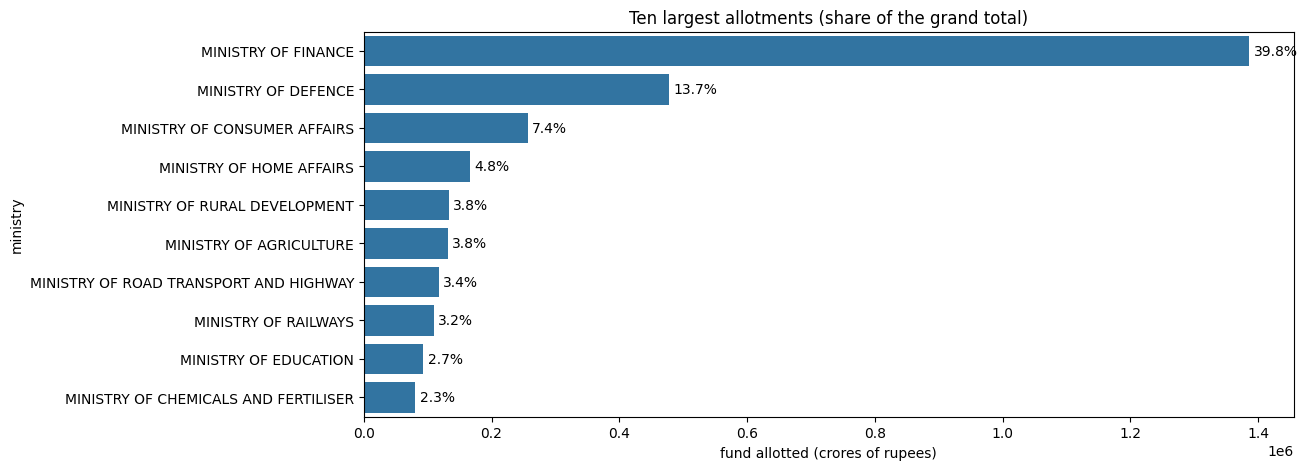

In [5]:
top = ministries.sort_values("fund", ascending=False).head(10)

plt.figure(figsize=(12, 5))
ax = sns.barplot(y="ministry", x="fund", data=top, color="tab:blue")
ax.bar_label(ax.containers[0], labels=[f"{share:.1f}%" for share in top["share (%)"]], padding=3)
plt.title("Ten largest allotments (share of the grand total)")
plt.xlabel("fund allotted (crores of rupees)")
plt.show()

The Ministry of Finance receives 1,386,273 crores, 39.8% of the grand total, followed by the Ministry of Defence (478,196 crores, 13.7%) and the Ministry of Consumer Affairs (256,948 crores, 7.4%). The next ones have between 2.3% and 4.8% each: Home Affairs, Rural Development, Agriculture, Road Transport and Highways, Railways, Education, and Chemicals and Fertiliser. The reference misses the tenth ministry, Chemicals and Fertiliser, because it selects only nine. The data gives one number per ministry, so it does not show what is inside the very large line of the Ministry of Finance; it should not be read as the spending of the ministry's own activities only.

## Share of the Budget

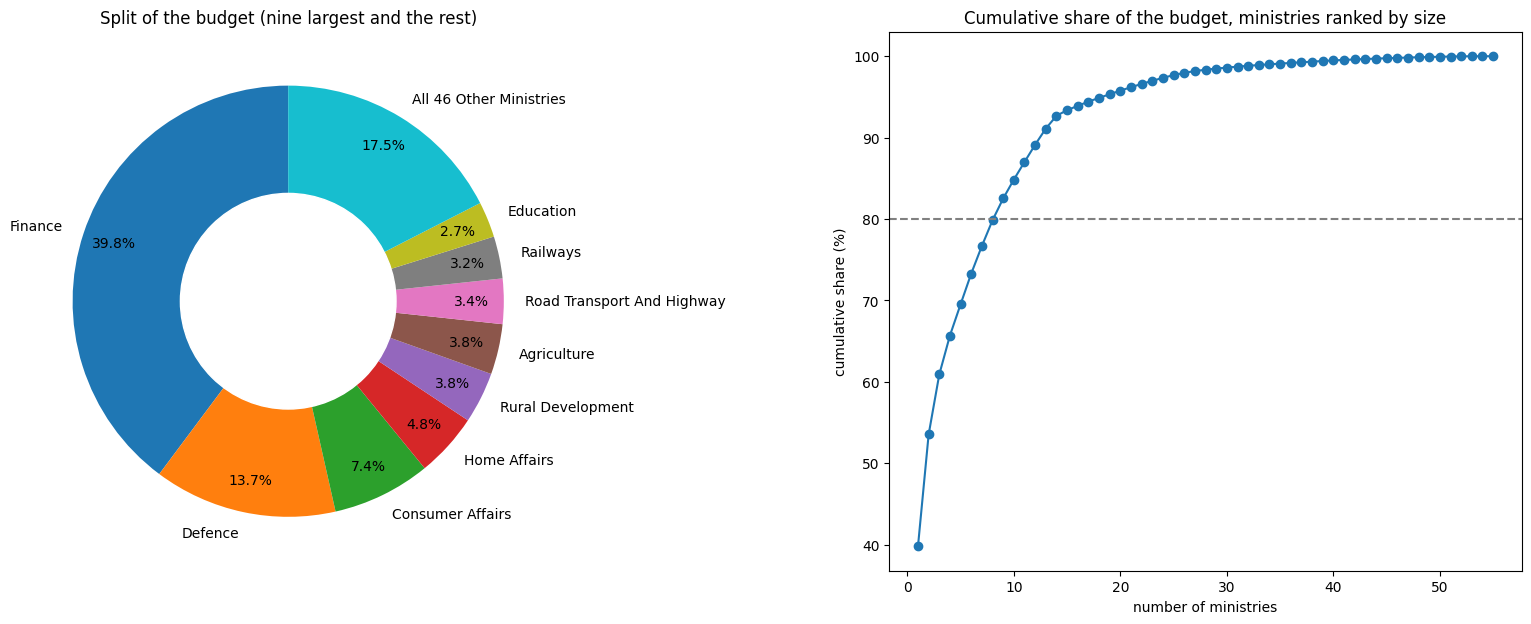

ministries needed to reach 50%, 80% and 90% of the budget: [2, 9, 13]


In [6]:
top9 = ministries.sort_values("fund", ascending=False).head(9)
others = pd.DataFrame({"ministry": [f"ALL {len(ministries) - 9} OTHER MINISTRIES"], "fund": [grand_total - top9["fund"].sum()]})
donut = pd.concat([top9[["ministry", "fund"]], others])

fig, axes = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"wspace": 0.45})
axes[0].pie(donut["fund"], labels=donut["ministry"].str.replace("MINISTRY OF ", "").str.title(), autopct="%1.1f%%", startangle=90, pctdistance=0.85)
axes[0].add_artist(plt.Circle((0, 0), 0.5, color="white"))
axes[0].set_title("Split of the budget (nine largest and the rest)")

cumulative = ministries["fund"].sort_values(ascending=False).cumsum().reset_index(drop=True) / grand_total * 100
axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker="o")
axes[1].axhline(80, color="grey", linestyle="--")
axes[1].set_title("Cumulative share of the budget, ministries ranked by size")
axes[1].set_xlabel("number of ministries"); axes[1].set_ylabel("cumulative share (%)")
plt.show()

print("ministries needed to reach 50%, 80% and 90% of the budget:", [int((cumulative < level).sum() + 1) for level in (50, 80, 90)])

The budget is very concentrated: two ministries (Finance and Defence) hold 53.5% of it, nine ministries reach 80% and thirteen reach 90%. The donut chart shows the split of the nine largest allotments and of all the others together (46 ministries, computed from the data), and the cumulative curve on the right shows how fast the share grows with the first few ministries.

## The Small Allotments

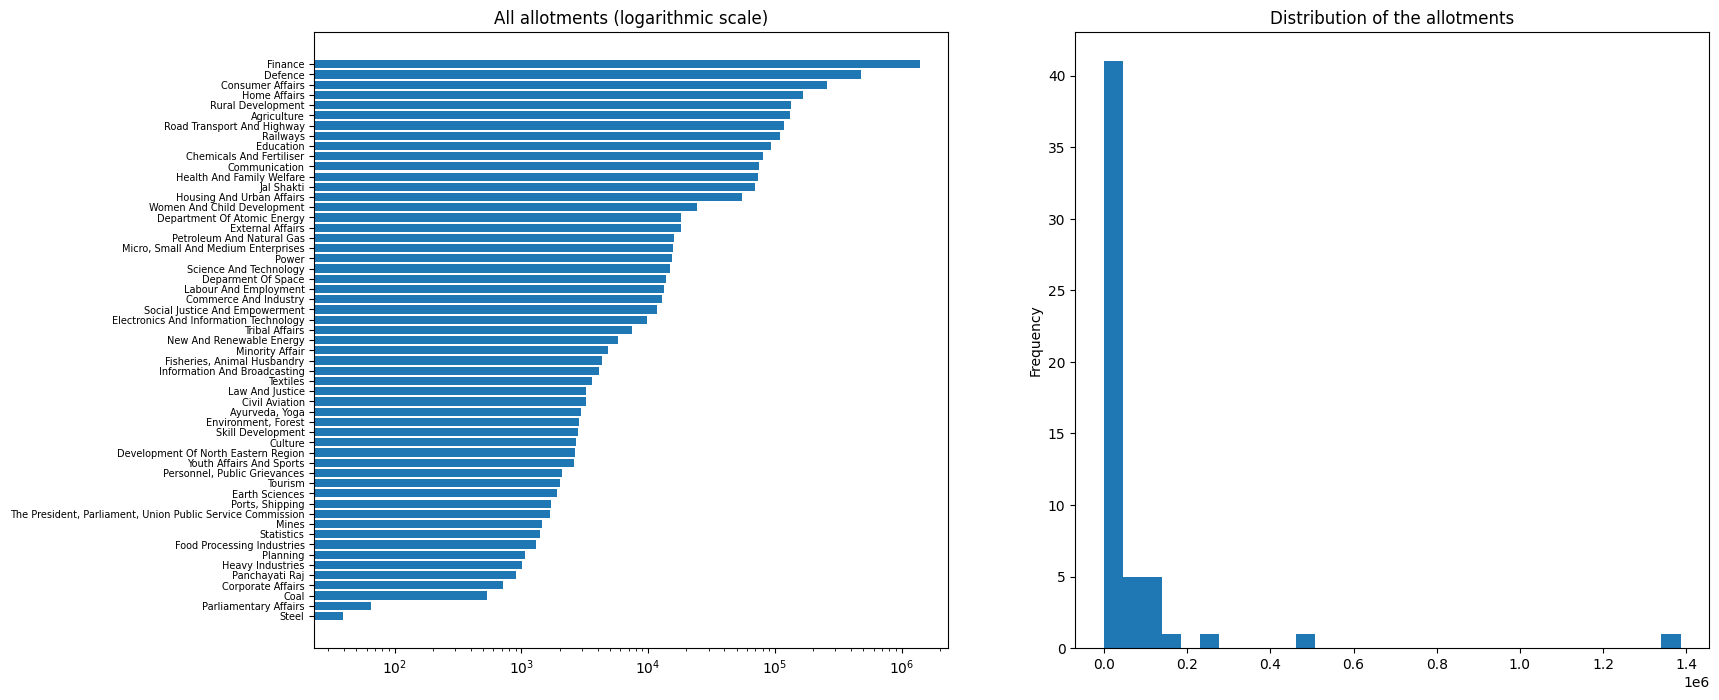

mean: 63332 | median: 5753
ministries with less than 1% of the budget: 41 of 55 | together: 7.3 %


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
ordered = ministries.sort_values("fund")
axes[0].barh(ordered["ministry"].str.replace("MINISTRY OF ", "").str.title(), ordered["fund"])
axes[0].set_xscale("log"); axes[0].set_title("All allotments (logarithmic scale)"); axes[0].tick_params(axis="y", labelsize=7)
ministries["fund"].plot(kind="hist", bins=30, ax=axes[1], title="Distribution of the allotments")
plt.show()

print("mean:", round(ministries["fund"].mean()), "| median:", round(ministries["fund"].median()))
print("ministries with less than 1% of the budget:", (ministries["share (%)"] < 1).sum(), "of", len(ministries), "| together:", round(ministries.loc[ministries["share (%)"] < 1, "share (%)"].sum(), 1), "%")

The allotments are extremely unequal: the mean (63,332 crores) is eleven times the median (5,753 crores), and 41 of the 55 ministries have less than 1% of the budget each and 7.3% together. On a linear scale the small ministries cannot be seen, which is why the reference groups them as "OTHERS"; a logarithmic scale (left) shows all of them, and the histogram (right) shows the long tail.

## Conclusion

**Reference approach.** The reference selects nine ministries by their row numbers in the file, adds a row "OTHERS" with a typed value (592,971.08), and draws a bar chart and a donut chart. It concludes that the Ministry of Finance receives 40% of the funds.

**Check of the reference.** The 55 ministries add up exactly to the grand total (3,483,235.63 crores). The typed "OTHERS" value is 15,699.65 crores too low, which is the allotment of the Ministry of Micro, Small and Medium Enterprises: this ministry is missing from the reference's chart. The share of the Ministry of Finance is 39.8%, not 40.0%. The grand total row and an empty row stay in the reference's table because `dropna()` is not assigned.

**Our analysis.** All figures are computed from the data and the ministries are ranked instead of selected by row numbers:

| Ministry | Fund (crores) | Share |
|---|---|---|
| Finance | 1,386,273 | 39.8% |
| Defence | 478,196 | 13.7% |
| Consumer Affairs | 256,948 | 7.4% |
| Home Affairs | 166,547 | 4.8% |
| Rural Development | 133,690 | 3.8% |
| Agriculture | 131,531 | 3.8% |
| Other 49 ministries | 930,051 | 26.7% |

Two ministries hold 53.5% of the budget, nine hold 80% and thirteen hold 90%; 41 of the 55 ministries have less than 1% each. The distribution is very skewed (mean 63,332 crores, median 5,753), so linear charts hide most ministries and a logarithmic scale or a cumulative curve is needed.

**Limitations.** The file gives one allotment per ministry for a single year: it does not show the previous years, the split between revenue and capital spending, or what is included in each ministry's line (the Ministry of Finance's line may include items beyond the work of the ministry). A share of the budget is not a measure of importance, and no conclusion can be drawn about the efficiency or the results of the spending.